# 建模
目录：
1. 下载数据
2. 了解数据
3. 数据可视化和预处理
4. 评估标准
5. 训练集/测试集分割
6. 建模过程
    1. OLS
    2. Random Forest with RFE
    3. Ridge Regression
    4. XGBoost
    5. LightGBM
7. 结果与比较

### 1. 下载数据

In [179]:
# boston
import pandas as pd
# 数据集是这样构造的，但version 1.2以后的sklearn版本里面没有这个数据集了
# from sklearn.datasets import load_boston
# boston = load_boston()
# data_boston = pd.DataFrame(boston.data, columns=boston.feature_names)
# data_boston['y'] = pd.Series(boston.target)

data_boston = pd.read_csv("data_boston.csv", index_col=0)

In [180]:
# avocado
# https://www.kaggle.com/datasets/neuromusic/avocado-prices?resource=download
data_avocado = pd.read_csv("./avocado.csv", index_col=0)
data_avocado.describe()

,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,year
count,18249.000000,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,18249.000000,18249.000000
mean,1.405978,8.506440e+05,2.930084e+05,2.951546e+05,2.283974e+04,2.396392e+05,1.821947e+05,5.433809e+04,3106.426507,2016.147899
std,0.402677,3.453545e+06,1.264989e+06,1.204120e+06,1.074641e+05,9.862424e+05,7.461785e+05,2.439660e+05,17692.894652,0.939938
min,0.440000,8.456000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,2015.000000
25%,1.100000,1.083858e+04,8.540700e+02,3.008780e+03,0.000000e+00,5.088640e+03,2.849420e+03,1.274700e+02,0.000000,2015.000000
50%,1.370000,1.073768e+05,8.645300e+03,2.906102e+04,1.849900e+02,3.974383e+04,2.636282e+04,2.647710e+03,0.000000,2016.000000
75%,1.660000,4.329623e+05,1.110202e+05,1.502069e+05,6.243420e+03,1.107834e+05,8.333767e+04,2.202925e+04,132.500000,2017.000000
max,3.250000,6.250565e+07,2.274362e+07,2.047057e+07,2.546439e+06,1.937313e+07,1.338459e+07,5.719097e+06,551693.650000,2018.000000


In [181]:
data_avocado

,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany
1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany
2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany
3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany
4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7,2018-02-04,1.63,17074.83,2046.96,1529.20,0.00,13498.67,13066.82,431.85,0.0,organic,2018,WestTexNewMexico
8,2018-01-28,1.71,13888.04,1191.70,3431.50,0.00,9264.84,8940.04,324.80,0.0,organic,2018,WestTexNewMexico
9,2018-01-21,1.87,13766.76,1191.92,2452.79,727.94,9394.11,9351.80,42.31,0.0,organic,2018,WestTexNewMexico
10,2018-01-14,1.93,16205.22,1527.63,2981.04,727.01,10969.54,10919.54,50.00,0.0,organic,2018,WestTexNewMexico


### 2. 了解数据

#### 2.1 Boston Housing

数据集都有以下14个属性:

- CRIM--城镇人均犯罪率）                                             ------【城镇人均犯罪率】
- ZN - 占地面积超过25,000平方英尺的住宅用地比例。             ------【住宅用地所占比例】
- INDUS - 每个城镇非零售业务的比例。                        ------【城镇中非商业用地占比例】
- CHAS - Charles River虚拟变量（如果是河道，则为1;否则为0    ------【查尔斯河虚拟变量，用于回归分析】
- NOX - 一氧化氮浓度（每千万份）                                             ------【环保指标】
- RM - 每间住宅的平均房间数                                                      ------【每栋住宅房间数】
- AGE - 1940年以前建造的自住单位比例                                     ------【1940年以前建造的自住单位比例 】
- DIS -波士顿的五个就业中心加权距离                                        ------【与波士顿的五个就业中心加权距离】
- RAD - 径向高速公路的可达性指数                                             ------【距离高速公路的便利指数】
- TAX - 每10,000美元的全额物业税率                                          ------【每一万美元的不动产税率】
- PTRATIO - 城镇的学生与教师比例                                             ------【城镇中教师学生比例】
- B - 1000（Bk - 0.63）^ 2其中Bk是城镇黑人的比例                   ------【城镇中黑人比例】
- LSTAT - 人口状况下降％                                                            ------【房东属于低等收入阶层比例】
- MEDV - 自有住房的中位数报价, 单位1000美元                         ------【自住房屋房价中位数】

#### 2.2 Avocado(牛油果)

The table below represents weekly 2018 retail scan data for National retail volume (units) and price. Retail scan data comes directly from retailers’ cash registers based on actual retail sales of Hass avocados. Starting in 2013, the table below reflects an expanded, multi-outlet retail data set. Multi-outlet reporting includes an aggregation of the following channels: grocery, mass, club, drug, dollar and military. The Average Price (of avocados) in the table reflects a per unit (per avocado) cost, even when multiple units (avocados) are sold in bags. The Product Lookup codes (PLU’s) in the table are only for Hass avocados. Other varieties of avocados (e.g. greenskins) are not included in this table.

- Date - The date of the observation
- AveragePrice - the average price of a single avocado
- type - conventional or organic
- year - the year
- Region - the city or region of the observation
- Total Volume - Total number of avocados sold
- 4046 - Total number of avocados with PLU 4046 sold
- 4225 - Total number of avocados with PLU 4225 sold
- 4770 - Total number of avocados with PLU 4770 sold

### 3.数据可视化和预处理

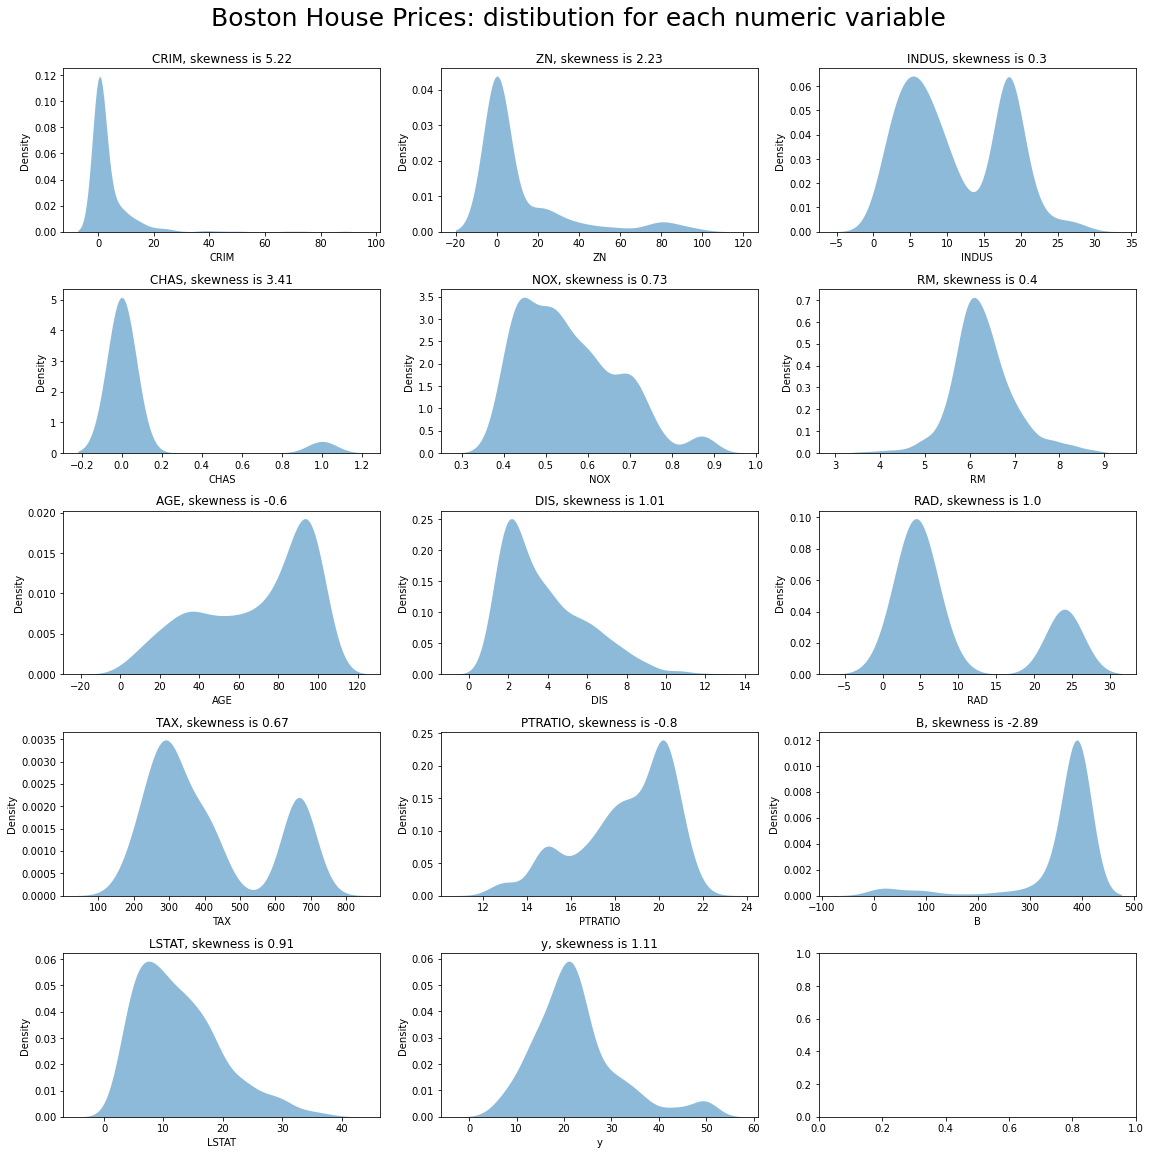

In [182]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

# Checking for distributions
def dist_custom(dataset, columns_list, rows, cols, suptitle):
    fig, axs = plt.subplots(rows, cols,figsize=(16,16))
    fig.suptitle(suptitle,y=1, size=25)
    axs = axs.flatten()
    for i, data in enumerate(columns_list):
        sns.kdeplot(dataset[data], ax=axs[i], fill=True,  alpha=.5, linewidth=0)
        axs[i].set_title(data + ', skewness is '+str(round(dataset[data].skew(axis = 0, skipna = True),2)))

dist_custom(dataset=data_boston, columns_list=data_boston.columns, rows=5, cols=3, suptitle='Boston House Prices: distibution for each numeric variable')
plt.tight_layout()

{'Roanoke', 'California', 'Portland', 'Philadelphia', 'Plains', 'HartfordSpringfield', 'Columbus', 'Nashville', 'Boise', 'DallasFtWorth', 'Jacksonville', 'Seattle', 'RaleighGreensboro', 'Southeast', 'LasVegas', 'RichmondNorfolk', 'PhoenixTucson', 'Houston', 'NewOrleansMobile', 'Albany', 'Spokane', 'NewYork', 'Denver', 'Louisville', 'StLouis', 'TotalUS', 'NorthernNewEngland', 'Chicago', 'GreatLakes', 'Midsouth', 'Syracuse', 'Detroit', 'Pittsburgh', 'Charlotte', 'LosAngeles', 'SanFrancisco', 'WestTexNewMexico', 'GrandRapids', 'SouthCarolina', 'MiamiFtLauderdale', 'Atlanta', 'BaltimoreWashington', 'Northeast', 'Tampa', 'Sacramento', 'SanDiego', 'West', 'HarrisburgScranton', 'CincinnatiDayton', 'BuffaloRochester', 'Orlando', 'Boston', 'SouthCentral', 'Indianapolis'}
{'conventional', 'organic'}


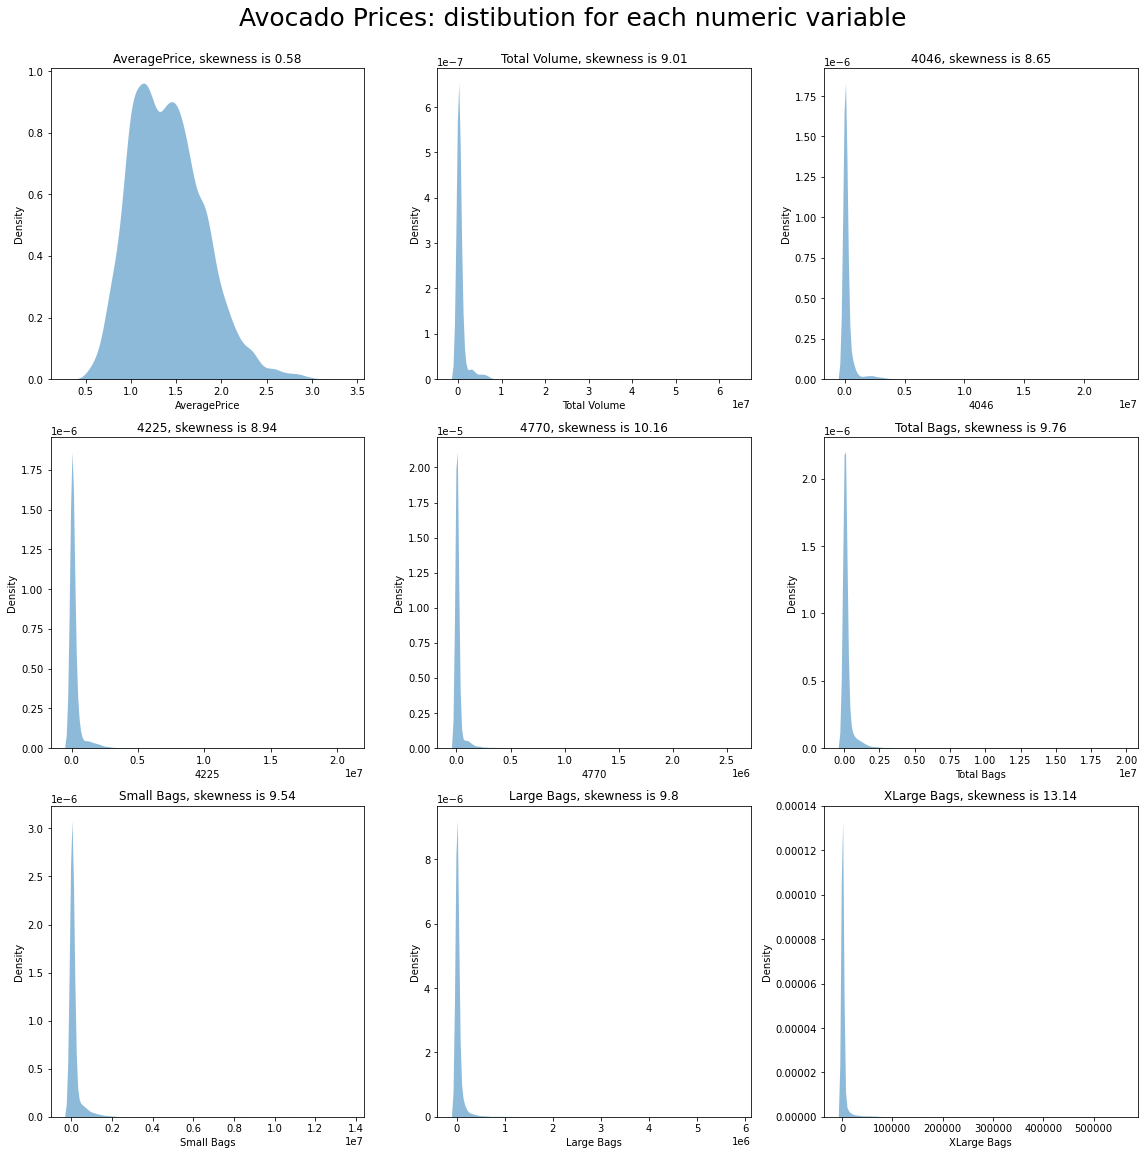

In [183]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt


data_avocado = pd.read_csv("./avocado.csv", index_col=0)
categorical_columns = ['region', 'type']
numeric_columns = ['AveragePrice', 'Total Volume','4046', '4225', '4770', 'Total Bags', 'Small Bags', 'Large Bags', 'XLarge Bags']

for c in categorical_columns:
    print(set(data_avocado[c].values))

data_avocado['type'] = data_avocado['type'].apply(lambda x: 1 if x == "organic" else 0)

# region_mapping = {}
# i = 0
# for r in set(data_avocado['region'].values):
#     region_mapping[r] = i
#     i += 1

# data_avocado['region'] = data_avocado['region'].apply(lambda x: region_mapping[x])

data_avocado['Date'] = data_avocado['Date'].apply(lambda x: int(pd.Timestamp(x).timestamp()))
# data_avocado.drop(columns='year', inplace=True)

dist_custom(dataset=data_avocado, columns_list=numeric_columns, rows=3, cols=3, suptitle='Avocado Prices: distibution for each numeric variable')
plt.tight_layout()

In [184]:
# Encoding 'region' (One Hot Encoding)
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(drop='first', handle_unknown='ignore')
ohe = pd.get_dummies(data=data_avocado, columns=['region'])
data_avocado = ohe
data_avocado.describe()

,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,...,region_SouthCarolina,region_SouthCentral,region_Southeast,region_Spokane,region_StLouis,region_Syracuse,region_Tampa,region_TotalUS,region_West,region_WestTexNewMexico
count,1.824900e+04,18249.000000,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,18249.000000,...,18249.000000,18249.000000,18249.000000,18249.000000,18249.000000,18249.000000,18249.000000,18249.000000,18249.000000,18249.000000
mean,1.471131e+09,1.405978,8.506440e+05,2.930084e+05,2.951546e+05,2.283974e+04,2.396392e+05,1.821947e+05,5.433809e+04,3106.426507,...,0.018522,0.018522,0.018522,0.018522,0.018522,0.018522,0.018522,0.018522,0.018522,0.018357
std,2.950676e+07,0.402677,3.453545e+06,1.264989e+06,1.204120e+06,1.074641e+05,9.862424e+05,7.461785e+05,2.439660e+05,17692.894652,...,0.134831,0.134831,0.134831,0.134831,0.134831,0.134831,0.134831,0.134831,0.134831,0.134243
min,1.420330e+09,0.440000,8.456000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.445731e+09,1.100000,1.083858e+04,8.540700e+02,3.008780e+03,0.000000e+00,5.088640e+03,2.849420e+03,1.274700e+02,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.471133e+09,1.370000,1.073768e+05,8.645300e+03,2.906102e+04,1.849900e+02,3.974383e+04,2.636282e+04,2.647710e+03,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.496534e+09,1.660000,4.329623e+05,1.110202e+05,1.502069e+05,6.243420e+03,1.107834e+05,8.333767e+04,2.202925e+04,132.500000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.521936e+09,3.250000,6.250565e+07,2.274362e+07,2.047057e+07,2.546439e+06,1.937313e+07,1.338459e+07,5.719097e+06,551693.650000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


### 4 评估标准


In [185]:
def Reg_Models_Evaluation_Metrics (model, X_train, y_train, X_test, y_test, y_pred):
    from sklearn.model_selection import cross_val_score
    from sklearn import metrics

    cv_score = cross_val_score(estimator = model, X = X_train, y = y_train, cv = 10)
    
    # Calculating Adjusted R-squared
    r2 = model.score(X_test, y_test)
    # Number of observations is the shape along axis 0
    n = X_test.shape[0]
    # Number of features (predictors, p) is the shape along axis 1
    p = X_test.shape[1]
    # Adjusted R-squared formula
    adjusted_r2 = 1-(1-r2)*(n-1)/(n-p-1)
    RMSE = np.sqrt(metrics.mean_squared_error(y_test, y_pred))
    R2 = model.score(X_test, y_test)
    CV_R2 = cv_score.mean()

    return R2, adjusted_r2, CV_R2, RMSE
    
    print('RMSE:', round(RMSE,4))
    print('R2:', round(R2,4))
    print('Adjusted R2:', round(adjusted_r2, 4) )
    print("Cross Validated R2: ", round(cv_score.mean(),4) )

### 5 训练/测试集合分割

In [186]:
X = data_boston.drop('y', axis=1)
y = data_boston['y']

X2 = data_avocado.drop('AveragePrice', axis=1)
y2 = data_avocado['AveragePrice']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)
X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size = 0.3, random_state = 42)

### 6. 模型训练

#### 6.1 LinearRegression

有两个包可以实现线性回归，一个是statsmodels，一个是sklearn，前者的好处是有个summary可以方便得看回归的细节，后者的好处是和其他机器学习包有一致的接口，这里用后者为主

In [187]:
import statsmodels.api as sm
md = sm.OLS(y_train, X_train)
result = md.fit()
print(result.summary())

# Model making a prediction on test data
y_pred = result.predict(X_test)

                                 OLS Regression Results                                
Dep. Variable:                      y   R-squared (uncentered):                   0.961
Model:                            OLS   Adj. R-squared (uncentered):              0.959
Method:                 Least Squares   F-statistic:                              639.0
Date:                Sat, 08 Jul 2023   Prob (F-statistic):                   2.28e-230
Time:                        10:59:01   Log-Likelihood:                         -1067.4
No. Observations:                 354   AIC:                                      2161.
Df Residuals:                     341   BIC:                                      2211.
Df Model:                          13                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [188]:
from sklearn.linear_model import LinearRegression

def train_lr(X_train,y_train,X_test,y_test):
    # Creating and training model
    lm = LinearRegression()
    lm.fit(X_train, y_train)

    # Model making a prediction on test data
    y_pred = lm.predict(X_test)

    ndf = [Reg_Models_Evaluation_Metrics(lm,X_train,y_train,X_test,y_test,y_pred)]

    lm_score = pd.DataFrame(data = ndf, columns=['R2 Score','Adjusted R2 Score','Cross Validated R2 Score','RMSE'])
    lm_score.insert(0, 'Model', 'Linear Regression')
    return lm_score

lm_score = train_lr(X_train,y_train,X_test,y_test)
boston_results = pd.DataFrame()
boston_results = pd.concat([boston_results, lm_score])
boston_results

,Model,R2 Score,Adjusted R2 Score,Cross Validated R2 Score,RMSE
0,Linear Regression,0.711226,0.684023,0.687535,4.63869


In [189]:
from sklearn.linear_model import LinearRegression

# Creating and training model
lm = LinearRegression()
lm.fit(X_train2, y_train2)

# Model making a prediction on test data
y_pred = lm.predict(X_test2)

ndf = [Reg_Models_Evaluation_Metrics(lm,X_train2,y_train2,X_test2,y_test2,y_pred)]

avocado_results = pd.DataFrame()
lm_score = pd.DataFrame(data = ndf, columns=['R2 Score','Adjusted R2 Score','Cross Validated R2 Score','RMSE'])
lm_score.insert(0, 'Model', 'Linear Regression')
avocado_results = pd.concat([avocado_results, lm_score])
avocado_results

,Model,R2 Score,Adjusted R2 Score,Cross Validated R2 Score,RMSE
0,Linear Regression,0.586335,0.581364,0.587778,0.258341


#### 6.2 Random Forest with RFE


In [190]:
from sklearn.ensemble import RandomForestRegressor

# Creating and training model
RandomForest_reg = RandomForestRegressor(n_estimators = 10, random_state = 0)
RandomForest_reg.fit(X_train, y_train)

# Model making a prediction on test data
y_pred = RandomForest_reg.predict(X_test)

ndf = [Reg_Models_Evaluation_Metrics(RandomForest_reg,X_train,y_train,X_test,y_test,y_pred)]

rf_score = pd.DataFrame(data = ndf, columns=['R2 Score','Adjusted R2 Score','Cross Validated R2 Score','RMSE'])
rf_score.insert(0, 'Model', 'Random Forest')
boston_results = pd.concat([boston_results, rf_score])
boston_results

,Model,R2 Score,Adjusted R2 Score,Cross Validated R2 Score,RMSE
0,Linear Regression,0.711226,0.684023,0.687535,4.638690
0,Random Forest,0.850410,0.836318,0.816168,3.338627


In [191]:
from sklearn.ensemble import RandomForestRegressor

# Creating and training model
RandomForest_reg = RandomForestRegressor(n_estimators = 10, random_state = 0)
RandomForest_reg.fit(X_train2, y_train2)

# Model making a prediction on test data
y_pred = RandomForest_reg.predict(X_test2)

ndf = [Reg_Models_Evaluation_Metrics(RandomForest_reg,X_train2,y_train2,X_test2,y_test2,y_pred)]

rf_score = pd.DataFrame(data = ndf, columns=['R2 Score','Adjusted R2 Score','Cross Validated R2 Score','RMSE'])
rf_score.insert(0, 'Model', 'Random Forest')
avocado_results = pd.concat([avocado_results, rf_score])
avocado_results

,Model,R2 Score,Adjusted R2 Score,Cross Validated R2 Score,RMSE
0,Linear Regression,0.586335,0.581364,0.587778,0.258341
0,Random Forest,0.902074,0.900897,0.892423,0.125695


In [192]:
from sklearn.feature_selection import RFE
from sklearn.pipeline import Pipeline

# create pipeline
rfe = RFE(estimator=RandomForestRegressor(), n_features_to_select=8)
model = RandomForestRegressor()
rf_pipeline = Pipeline(steps=[('s',rfe),('m',model)])
rf_pipeline.fit(X_train, y_train)

# Model making a prediction on test data
y_pred = rf_pipeline.predict(X_test)

ndf = [Reg_Models_Evaluation_Metrics(rf_pipeline,X_train,y_train,X_test,y_test,y_pred)]

rfe_score = pd.DataFrame(data = ndf, columns=['R2 Score','Adjusted R2 Score','Cross Validated R2 Score','RMSE'])
rfe_score.insert(0, 'Model', 'Random Forest with RFE')
boston_results = pd.concat([boston_results, rfe_score])
boston_results

,Model,R2 Score,Adjusted R2 Score,Cross Validated R2 Score,RMSE
0,Linear Regression,0.711226,0.684023,0.687535,4.638690
0,Random Forest,0.850410,0.836318,0.816168,3.338627
0,Random Forest with RFE,0.877133,0.865559,0.821174,3.025754


In [193]:
# from sklearn.ensemble import RandomForestRegressor

# # create pipeline
# rfe = RFE(estimator=RandomForestRegressor(), n_features_to_select=60)
# model = RandomForestRegressor()
# rf_pipeline = Pipeline(steps=[('s',rfe),('m',model)])
# rf_pipeline.fit(X_train, y_train)

# # Model making a prediction on test data
# y_pred = rf_pipeline.predict(X_test)

# ndf = [Reg_Models_Evaluation_Metrics(rf_pipeline,X_train2,y_train2,X_test2,y_test2,y_pred)]

# rfe_score = pd.DataFrame(data = ndf, columns=['R2 Score','Adjusted R2 Score','Cross Validated R2 Score','RMSE'])
# rfe_score.insert(0, 'Model', 'Random Forest with RFE')
# avocado_results = pd.concat([avocado_results, rfe_score])
# avocado_results

#### 6.3 Ridge Regression

In [194]:
from sklearn.linear_model import Ridge

# Creating and training model
ridge_reg = Ridge(alpha=3, solver="cholesky")
ridge_reg.fit(X_train, y_train)

# Model making a prediction on test data
y_pred = ridge_reg.predict(X_test)

ndf = [Reg_Models_Evaluation_Metrics(ridge_reg,X_train,y_train,X_test,y_test,y_pred)]

rr_score = pd.DataFrame(data = ndf, columns=['R2 Score','Adjusted R2 Score','Cross Validated R2 Score','RMSE'])
rr_score.insert(0, 'Model', 'Ridge Regression')
boston_results = pd.concat([boston_results, rr_score])
boston_results

,Model,R2 Score,Adjusted R2 Score,Cross Validated R2 Score,RMSE
0,Linear Regression,0.711226,0.684023,0.687535,4.638690
0,Random Forest,0.850410,0.836318,0.816168,3.338627
0,Random Forest with RFE,0.877133,0.865559,0.821174,3.025754
0,Ridge Regression,0.698880,0.670513,0.683222,4.736815


In [195]:
from sklearn.linear_model import Ridge

# Creating and training model
ridge_reg = Ridge(alpha=3, solver="cholesky")
ridge_reg.fit(X_train2, y_train2)

# Model making a prediction on test data
y_pred = ridge_reg.predict(X_test2)

ndf = [Reg_Models_Evaluation_Metrics(ridge_reg,X_train2,y_train2,X_test2,y_test2,y_pred)]

rr_score = pd.DataFrame(data = ndf, columns=['R2 Score','Adjusted R2 Score','Cross Validated R2 Score','RMSE'])
rr_score.insert(0, 'Model', 'Ridge Regression')
avocado_results = pd.concat([avocado_results, rr_score])
avocado_results

/Users/jason/program/anaconda3/lib/python3.8/site-packages/sklearn/linear_model/_ridge.py:147: LinAlgWarning: Ill-conditioned matrix (rcond=2.65045e-19): result may not be accurate.
  return linalg.solve(A, Xy, sym_pos=True,
/Users/jason/program/anaconda3/lib/python3.8/site-packages/sklearn/linear_model/_ridge.py:147: LinAlgWarning: Ill-conditioned matrix (rcond=2.94523e-19): result may not be accurate.
  return linalg.solve(A, Xy, sym_pos=True,
/Users/jason/program/anaconda3/lib/python3.8/site-packages/sklearn/linear_model/_ridge.py:147: LinAlgWarning: Ill-conditioned matrix (rcond=2.93872e-19): result may not be accurate.
  return linalg.solve(A, Xy, sym_pos=True,
/Users/jason/program/anaconda3/lib/python3.8/site-packages/sklearn/linear_model/_ridge.py:147: LinAlgWarning: Ill-conditioned matrix (rcond=2.947e-19): result may not be accurate.
  return linalg.solve(A, Xy, sym_pos=True,
/Users/jason/program/anaconda3/lib/python3.8/site-packages/sklearn/linear_model/_ridge.py:147: LinAlgW

,Model,R2 Score,Adjusted R2 Score,Cross Validated R2 Score,RMSE
0,Linear Regression,0.586335,0.581364,0.587778,0.258341
0,Random Forest,0.902074,0.900897,0.892423,0.125695
0,Ridge Regression,0.586252,0.581280,0.587796,0.258367


#### 6.4 XGBoost

In [196]:
from xgboost import XGBRegressor
# create an xgboost regression model
XGBR = XGBRegressor(n_estimators=1000, max_depth=7, eta=0.1, subsample=0.8, colsample_bytree=0.8)

XGBR.fit(X_train, y_train)
# Model making a prediction on test data
y_pred = XGBR.predict(X_test)

ndf = [Reg_Models_Evaluation_Metrics(XGBR,X_train,y_train,X_test,y_test,y_pred)]

XGBR_score = pd.DataFrame(data = ndf, columns=['R2 Score','Adjusted R2 Score','Cross Validated R2 Score','RMSE'])
XGBR_score.insert(0, 'Model', 'XGBoost')
boston_results = pd.concat([boston_results, XGBR_score])
boston_results

#### 6.5 LightGBM

https://lightgbm.readthedocs.io/en/latest/pythonapi/lightgbm.LGBMRegressor.html

In [213]:
import lightgbm as lgb

lgbm = lgb.LGBMRegressor(
        num_leaves=63,
        learning_rate=0.06,
        n_estimators=300,
        feature_fraction=0.5,
        feature_fraction_bynode=0.5,
        bagging_fraction=0.8,
        bagging_freq=5
)

lgbm.fit(X_train, y_train, 
        eval_set=[
                (X_train, y_train),
                (X_test, y_test),
        ],
        # eval_metric=["l2"],
        early_stopping_rounds = 5
        )

y_pred = lgbm.predict(X_test)

ndf = [Reg_Models_Evaluation_Metrics(lgbm,X_train,y_train,X_test,y_test,y_pred)]

lgbm_score = pd.DataFrame(data = ndf, columns=['R2 Score','Adjusted R2 Score','Cross Validated R2 Score','RMSE'])
lgbm_score.insert(0, 'Model', 'LGBT')
boston_results = pd.concat([boston_results, lgbm_score])
boston_results

[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] feature_fraction is set=0.5, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.5
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[1]	training's l2: 81.8645	valid_1's l2: 71.8656
Training until validation scores don't improve for 5 rounds
[2]	training's l2: 75.754	valid_1's l2: 67.2291
[3]	training's l2: 72.1425	valid_1's l2: 64.0346
[4]	training's l2: 68.4943	valid_1's l2: 60.7851
[5]	training's l2: 64.332	valid_1's l2: 56.7986
[6]	training's l2: 59.6897	valid_1's l2: 52.8858
[7]	training's l2: 55.8727	valid_1's l2: 49.5709
[8]	training's l2: 52.211	valid_1's l2: 46.8111
[9]	training's l2: 48.2421	valid_1's l2: 43.4819
[10]	training's l2: 44.7443	valid_1's l2: 40.3806
[11]	training's l2: 41.6596	valid_1's l2: 37.7922
[12]	training's l2: 39.8088	valid_1's l2: 36.2862
[13

,Model,R2 Score,Adjusted R2 Score,Cross Validated R2 Score,RMSE
0,Linear Regression,0.711226,0.684023,0.687535,4.638690
0,Random Forest,0.850410,0.836318,0.816168,3.338627
0,Random Forest with RFE,0.877133,0.865559,0.821174,3.025754
0,Ridge Regression,0.698880,0.670513,0.683222,4.736815
0,LGBT,0.865027,0.852312,0.823942,3.171318
0,LGBT,0.839178,0.824028,0.819768,3.461694
0,LGBT,0.847729,0.833385,0.819768,3.368407
0,LGBT,0.847729,0.833385,0.819768,3.368407
0,LGBT,0.861285,0.848218,0.817880,3.214975
0,LGBT,0.866509,0.853934,0.815397,3.153860


In [220]:
import lightgbm as lgb

lgbm = lgb.LGBMRegressor(
        num_leaves=63,
        # num_leaves=123,
        learning_rate=0.2,
        n_estimators=400,
        feature_fraction=0.7,
        feature_fraction_bynode=0.7,
        bagging_fraction=0.8,
        bagging_freq=5
)

lgbm.fit(X_train2, y_train2, 
        eval_set=[
                (X_train2, y_train2),
                (X_test2, y_test2),
        ],
        # eval_metric=["l2"],
        early_stopping_rounds = 5
        )

y_pred = lgbm.predict(X_test2)

ndf = [Reg_Models_Evaluation_Metrics(lgbm,X_train2,y_train2,X_test2,y_test2,y_pred)]

lgbm_score = pd.DataFrame(data = ndf, columns=['R2 Score','Adjusted R2 Score','Cross Validated R2 Score','RMSE'])
lgbm_score.insert(0, 'Model', 'LGBT')
avocado_results = pd.concat([avocado_results, lgbm_score])
avocado_results

[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] feature_fraction is set=0.7, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[1]	training's l2: 0.119273	valid_1's l2: 0.11955
Training until validation scores don't improve for 5 rounds
[2]	training's l2: 0.0925989	valid_1's l2: 0.0944995
[3]	training's l2: 0.0714903	valid_1's l2: 0.0745393
[4]	training's l2: 0.057818	valid_1's l2: 0.0615707
[5]	training's l2: 0.0467801	valid_1's l2: 0.0507302
[6]	training's l2: 0.0389746	valid_1's l2: 0.0432789
[7]	training's l2: 0.0329883	valid_1's l2: 0.0376579
[8]	training's l2: 0.0286782	valid_1's l2: 0.0336396
[9]	training's l2: 0.0254796	valid_1's l2: 0.0306023
[10]	training's l2: 0.0229438	valid_1's l2: 0.0281457
[11]	training's l2: 0.0206167	valid_1's l2: 0.0259415
[12]	train

,Model,R2 Score,Adjusted R2 Score,Cross Validated R2 Score,RMSE
0,Linear Regression,0.586335,0.581364,0.587778,0.258341
0,Random Forest,0.902074,0.900897,0.892423,0.125695
0,Ridge Regression,0.586252,0.581280,0.587796,0.258367
0,LGBT,0.935020,0.934239,0.931716,0.102390
0,LGBT,0.897451,0.896219,0.891616,0.128627
0,LGBT,0.897451,0.896219,0.891616,0.128627
0,LGBT,0.939084,0.938352,0.934124,0.099137
0,LGBT,0.941605,0.940904,0.935935,0.097063
0,LGBT,0.935020,0.934239,0.931716,0.102390
0,LGBT,0.927834,0.926966,0.927742,0.107904


### 7. 结果与比较


#### 7.1 boston housing


In [199]:
boston_results

,Model,R2 Score,Adjusted R2 Score,Cross Validated R2 Score,RMSE
0,Linear Regression,0.711226,0.684023,0.687535,4.638690
0,Random Forest,0.850410,0.836318,0.816168,3.338627
0,Random Forest with RFE,0.877133,0.865559,0.821174,3.025754
0,Ridge Regression,0.698880,0.670513,0.683222,4.736815
0,LGBT,0.865027,0.852312,0.823942,3.171318


#### 7.2 Avocado

In [200]:
avocado_results

,Model,R2 Score,Adjusted R2 Score,Cross Validated R2 Score,RMSE
0,Linear Regression,0.586335,0.581364,0.587778,0.258341
0,Random Forest,0.902074,0.900897,0.892423,0.125695
0,Ridge Regression,0.586252,0.581280,0.587796,0.258367
0,LGBT,0.935020,0.934239,0.931716,0.102390


参考资料：
- https://www.kaggle.com/code/marcinrutecki/regression-models-evaluation-metrics/notebook